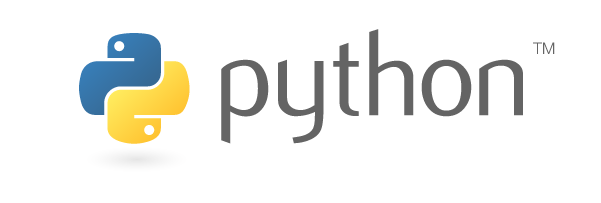

Bryan Robalino
Repositorio:https://github.com/bjrobalino22/machineLearning 


In [49]:
from IPython.display import Image, display
display(Image(filename="img/python_logo.png"))

## 01MIAR - Python 101, Data Types

print ("Bryan Robalino\nRepositorio:https://github.com/bjrobalino22/machineLearning ")

# Examen del Tercer Parcial 
## Regresión lineal
Dado el archivo **movie_genre_classification_final.csv** se encuentra un base de datos con información de **50000 películas** que incluyen variables como: <br>
 * Título,
 * Año de estreno,
 * Duración,
 * Puntuación promedio,
 * Número de votos,
 * Presupuesto,
 * Ingresos en taquilla,
 * Número de premios obtenidos,
 * Entre otras caracterisiticas.
Como parate del análisis de predicción, se desea estudiar la relación entre el:<br>
* Presupuesto de una película
y sus caracteristicas cuantitativas, para estimar la **recaudación en taquilla (BoxOffice_USD)**. Para ello, se plantea entrenar un modelo de regresión lineal.<br>

# Objetivo 
Predecir el valor de la variable **BoxOffice_USD** a partir de variables numéricas independientes disponibles en el dataset, tales como:<br>
* Budget_USD (Presupuesto en dólares)
* Duration (Duración en minutos)
* Ratting (Calificiación Promedio"
* Votes (Número de votos)
* Num_Awards (Número de premios obtenidos)
* Critic_reviews (Números de reseñas de criticos)

El dataset fue extraido desder <a href="https://www.kaggle.com/datasets/therohithanand/movie-genre-classification">DataSet<a> <br>

## Entrega esperada
* Código bien estructurado y comentado
* Gráficos claros en los pasos 2, 4 y 5.
* Breve análisis escrito de lso los resultados obtenidos.



In [50]:
# Imports necesarios
import numpy as np
import pandas as pd
import seaborn as sb
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [15]:
# Lectura de dato#cargamos los datos de entrada
data = pd.read_csv('movie_genre_classification_final.csv')

In [16]:
# Visualizacizón del conjunto de datos
# Gráfico de correlación
plt.figure(figsize=(10, 6))
sns.heatmap(df[variables].corr(), annot=True, cmap='coolwarm')
plt.title("Matriz de correlación entre variables numéricas")
plt.show()


,Title,Year,Director,Duration,Rating,Votes,Description,Language,Country,Budget_USD,BoxOffice_USD,Genre,Production_Company,Content_Rating,Lead_Actor,Num_Awards,Critic_Reviews
0,Winds of Fate 4,1980,R. Lee,167,4.1,182425,A touching love story with heartwarming moments.,Spanish,China,39979615,179936008,Romance,DreamWorks,R,Kangana Ranaut,8,229
1,Firestorm 11,2014,S. Chen,166,4.1,449351,A fast-paced thriller with intense action scenes.,Korean,China,116404774,802121619,Action,Netflix,R,Kangana Ranaut,20,466
2,Silent Echo 2,2016,A. Khan,170,4.1,363328,A fast-paced thriller with intense action scenes.,Korean,Japan,166261330,225526871,Action,Pixar,PG,Amitabh Bachchan,16,539
3,City Lights 4,1982,L. Zhang,170,9.9,62371,An emotional journey exploring complex charact...,Japanese,Japan,28861315,69813738,Drama,Netflix,NC-17,Natalie Portman,15,606
4,Broken Truth 1,1990,L. Zhang,91,5.3,4600,An imaginative world filled with magic and won...,Korean,USA,43890403,375136716,Fantasy,Studio Ghibli,PG,Chris Evans,6,330


C:\Users\Asus\AppData\Local\Temp\ipykernel_22696\4042043569.py:25: UserWarning: Glyph 128270 (\N{RIGHT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Asus\anaconda3\envs\machinelearnig\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128270 (\N{RIGHT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


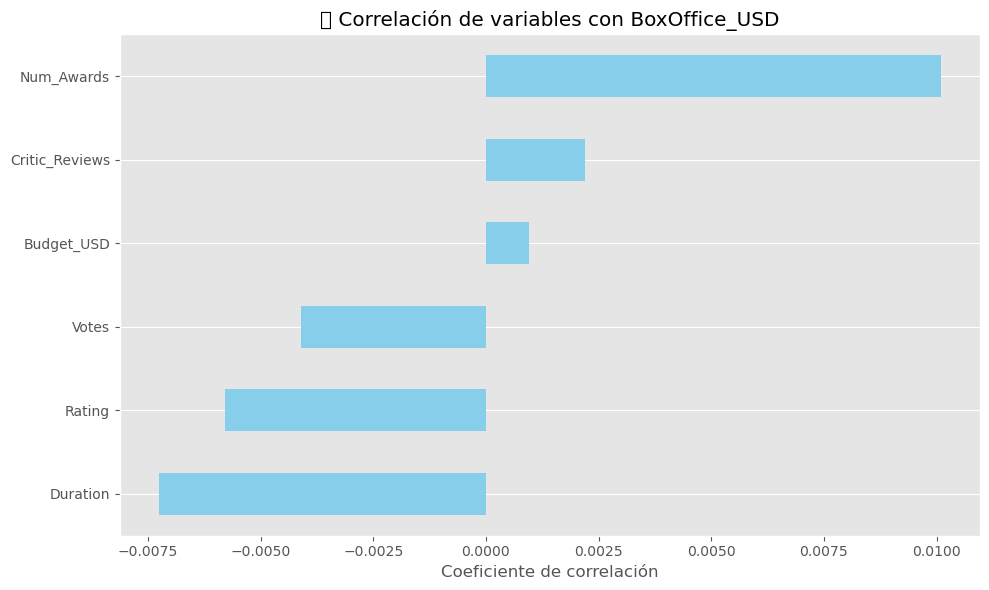

In [46]:

# Cargar y limpiar el DataFrame
data = pd.read_csv('movie_genre_classification_final.csv')
data = data.dropna()

# Variables que nos interesan
variables = [
    'Budget_USD',
    'Duration',
    'Rating',
    'Votes',
    'Num_Awards',
    'Critic_Reviews',
    'BoxOffice_USD'  # Variable objetivo
]

# Calcular la matriz de correlación
correlaciones = data[variables].corr()['BoxOffice_USD'].drop('BoxOffice_USD')

# 📊 Gráfico de barras
plt.figure(figsize=(10, 6))
correlaciones.sort_values(ascending=True).plot(kind='barh', color='skyblue')
plt.title('🔎 Correlación de variables con BoxOffice_USD')
plt.xlabel('Coeficiente de correlación')
plt.grid(axis='x')
plt.tight_layout()
plt.show()


Coefficients:
Budget_USD: 0.01
Duration: -87880.19
Rating: -1214600.32
Votes: 1.37
Num_Awards: 598146.30
Critic_Reviews: 3789.16

Independent term (Intercept):
528031847.59

Mean squared error: 83696224592480544.00
Variance score (R²): -0.00


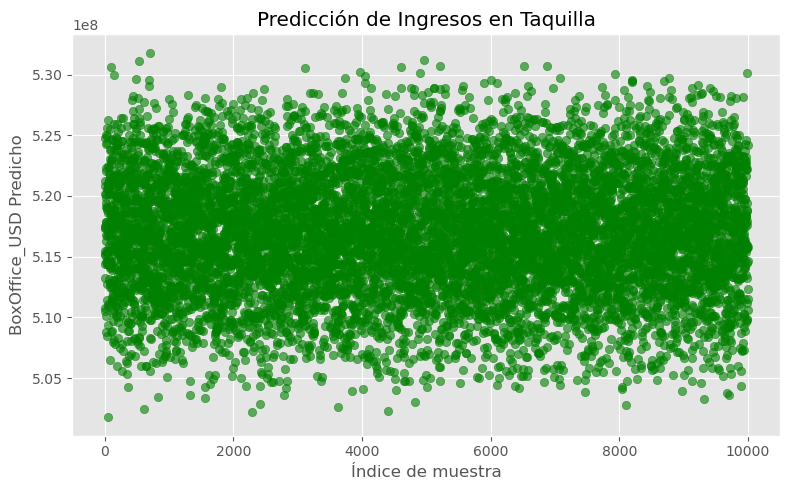

In [42]:
#Construcción del modelo de regresión lineal

# Variables predictoras y objetivo
X = data[['Budget_USD', 'Duration', 'Rating', 'Votes', 'Num_Awards', 'Critic_Reviews']]
y = data['BoxOffice_USD']

# División entrenamiento
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modelo de regresión lineal
modelo = LinearRegression()
modelo.fit(X_train, y_train)

# Predicciones
y_pred = modelo.predict(X_test)

# Resultados numericos
print("Coefficients:")
for feature, coef in zip(X.columns, modelo.coef_):
    print(f"{feature}: {coef:.2f}")

print("\nIndependent term (Intercept):")
print(f"{modelo.intercept_:.2f}")

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nMean squared error: %.2f" % mse)
print("Variance score (R²): %.2f" % r2)

# Gráfico:
plt.figure(figsize=(8, 5))
plt.scatter(range(len(y_pred)), y_pred, color='green', alpha=0.6)
plt.xlabel('Índice de muestra')
plt.ylabel('BoxOffice_USD Predicho')
plt.title('Predicción de Ingresos en Taquilla')
plt.grid(True)
plt.tight_layout()
plt.show()

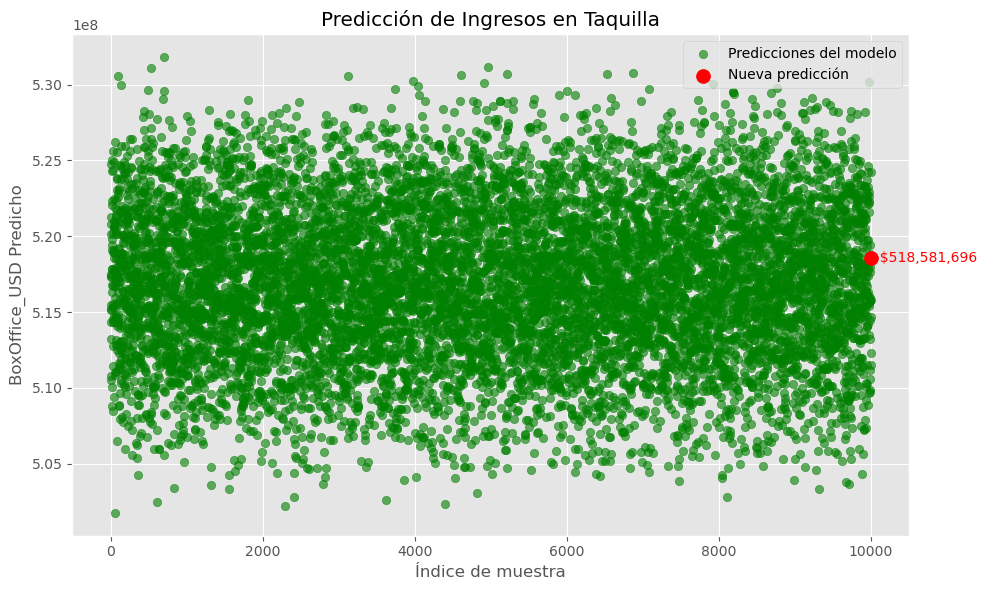

🔮 Predicción de ingresos en taquilla (BoxOffice_USD):
$518,581,696.31


In [45]:
# Predicción de nuevos ejemplos
# codigo generado en chat gtp
nueva_pelicula = {
    'Budget_USD': [120_000_000],     # Presupuesto en dólares
    'Duration': [130],               # Duración en minutos
    'Rating': [7.5],                 # Calificación promedio
    'Votes': [250_000],              # Número de votos
    'Num_Awards': [15],              # Premios ganados
    'Critic_Reviews': [300]          # Reseñas de críticos
}

# Crear DataFrame de una fila
entrada = pd.DataFrame.from_dict(nueva_pelicula)

# Predecir ingresos en taquilla
prediccion = modelo.predict(entrada)
# grafico 
plt.figure(figsize=(10, 6))
plt.scatter(range(len(y_pred)), y_pred, color='green', alpha=0.6, label='Predicciones del modelo')

# Agregar el punto de la nueva predicción
plt.scatter(len(y_pred), prediccion[0], color='red', s=100, label='Nueva predicción')
plt.text(len(y_pred), prediccion[0], f'  ${prediccion[0]:,.0f}', va='center', color='red', fontsize=10)

# Etiquetas y diseño
plt.xlabel('Índice de muestra')
plt.ylabel('BoxOffice_USD Predicho')
plt.title('Predicción de Ingresos en Taquilla')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

print("Predicción de ingresos en taquilla (BoxOffice_USD):")
print(f"${prediccion[0]:,.2f}")

In [47]:
print("En base a a los graficos y mas a los valores de correlacion del primer gracfico podemos decir que los datos entrenados ponderan de gran manera los premiso recividos para un gran aumento de los ingresoso en taquilla ")

En base a a los graficos y mas a los valores de correlacion del primer gracfico podemos decir que los datos entrenados ponderan de gran manera los premiso recividos para un gran aumento de los ingresoso en taquilla 
